# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve.


Large Language Models (LLMs) are advanced artificial intelligence systems trained on massive amounts of text to understand and generate human language. They use deep learning techniques, especially the Transformer architecture, to capture meaning, grammar, and context. Designed for tasks like answering questions, summarizing documents, translating languages, writing content, and holding conversations, LLMs act as versatile tools that simulate human-like communication by predicting the most likely words or phrases in a given context.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 62.4 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = "gpt2"   # TODO: choose a causal LM checkpoint, e.g., 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)   # TODO: load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # TODO: load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


Original Text: I am fatima ezzahra, I usually like having coffee in the moring. However, since it is Ramadan, I drink it at suhour. However it keeps me awake
Tokens: ['I', 'Ġam', 'Ġfat', 'ima', 'Ġe', 'zz', 'ah', 'ra', ',', 'ĠI', 'Ġusually', 'Ġlike', 'Ġhaving', 'Ġcoffee', 'Ġin', 'Ġthe', 'Ġmor', 'ing', '.', 'ĠHowever', ',', 'Ġsince', 'Ġit', 'Ġis', 'ĠRamadan', ',', 'ĠI', 'Ġdrink', 'Ġit', 'Ġat', 'Ġsu', 'hour', '.', 'ĠHowever', 'Ġit', 'Ġkeeps', 'Ġme', 'Ġawake']
Token IDs: [40, 716, 3735, 8083, 304, 3019, 993, 430, 11, 314, 3221, 588, 1719, 6891, 287, 262, 2146, 278, 13, 2102, 11, 1201, 340, 318, 37604, 11, 314, 4144, 340, 379, 424, 9769, 13, 2102, 340, 7622, 502, 21693]


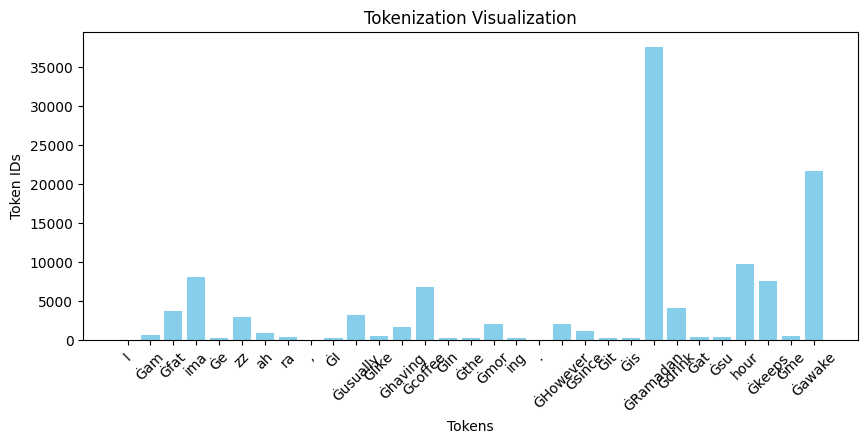

In [3]:
text = "I am fatima ezzahra, I usually like having coffee in the moring. However, since it is Ramadan, I drink it at suhour. However it keeps me awake"  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Tokenization Visualization"    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()


## 🌟 Exercise 3 · Token IDs and special prefixes


In [5]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

#  Iterate over tokens and token_ids, printing each mapping
for token, token_id in zip(tokens, token_ids):
    print(f"Token: {token} --> ID: {token_id}")




Token: I --> ID: 40
Token: Ġam --> ID: 716
Token: Ġfat --> ID: 3735
Token: ima --> ID: 8083
Token: Ġe --> ID: 304
Token: zz --> ID: 3019
Token: ah --> ID: 993
Token: ra --> ID: 430
Token: , --> ID: 11
Token: ĠI --> ID: 314
Token: Ġusually --> ID: 3221
Token: Ġlike --> ID: 588
Token: Ġhaving --> ID: 1719
Token: Ġcoffee --> ID: 6891
Token: Ġin --> ID: 287
Token: Ġthe --> ID: 262
Token: Ġmor --> ID: 2146
Token: ing --> ID: 278
Token: . --> ID: 13
Token: ĠHowever --> ID: 2102
Token: , --> ID: 11
Token: Ġsince --> ID: 1201
Token: Ġit --> ID: 340
Token: Ġis --> ID: 318
Token: ĠRamadan --> ID: 37604
Token: , --> ID: 11
Token: ĠI --> ID: 314
Token: Ġdrink --> ID: 4144
Token: Ġit --> ID: 340
Token: Ġat --> ID: 379
Token: Ġsu --> ID: 424
Token: hour --> ID: 9769
Token: . --> ID: 13
Token: ĠHowever --> ID: 2102
Token: Ġit --> ID: 340
Token: Ġkeeps --> ID: 7622
Token: Ġme --> ID: 502
Token: Ġawake --> ID: 21693


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.


Ġ tells the model “this token starts after a space,” helping it reconstruct text correctly when decoding.


## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [8]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "Artificial intelligence gives machines and systems the ability to immitate human behaviors"  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.7,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input: Artificial intelligence gives machines and systems the ability to immitate human behaviors
Generated Output: Artificial intelligence gives machines and systems the ability to immitate human behaviors, to move objects, to think about what they see and hear, to learn new ways to do things, and to do things that are more natural than humans.

Human-AI systems are designed to be able to do things that humans can't, which is a huge win for AI.


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


- Temperature changes the style the most — low values make text predictable and factual, high values make it creative and varied.
- Max new tokens changes the length — short values give concise outputs, long values allow extended, detailed continuations.

Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)